In [ ]:
## For Figure 5 and Table S2 in benchmarking paper
## Plot seasonal cycle of GPP, LH, and residuals at flux tower sites compared to FATES
## use precip at each site to find average dry season and indicate on figure with light tan bar

In [59]:
import numpy as np
#
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#
## this next library contains some helper functions for reshaping FATES variables into easier to work with dimensions
import ctsm_py.fates_xarray_funcs as fa       
#
import textwrap
from cmcrameri import cm
import cartopy
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader
import pandas as pd
from scipy.ndimage import uniform_filter1d


In [2]:
### Read in FATES file
# read in FATES output
fates_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/SummaryFiles/'
fates_tag='hydro_comp_bmort_kmax_tune_sapflow_kmax3_5xHR_fixSLA_vcmax40.55_fixHR_branch'
fates_file=fates_tag+'.elm.h2.cat.nc'
fates = xr.open_dataset(fates_path+fates_file)

In [3]:
## Get FATES GPP at each site

## Paracou, French Guiana
par_lat=5.2787
par_lon=360.-52.9248
par_dt=-3 ## time in CSV file is local time, so we don't need to apply this to observed data

### Tapajos (TAP) - Brazil - UTC-3
tap_lat=-3.3  
tap_lon=305.0
tap_dt=-4 # solar time is UTC - 3.5
tap_dt2=-3 # flux tower data timestamp is beginning of measurement interval

## Tanguro - Brazil
tan_lat = -13.08 
tan_lon = 307.59
tan_dt = -4 # GMT-4 -- for FATES simulations
tan_dt2 = 0 ## flux tower data is in local time

## K34 -- Brazil
k34_lat = -2.6091
k34_lon = 360.-60.2093
k34_dt = -4

In [4]:
import cftime

def cftime_to_doy(cf_datetime_array):
  """
  Converts an array (or list) of cftime.DatetimeNoLeap() objects to an array of DOY values.

  Args:
    cf_datetime_array: An iterable (e.g., list, array) of cftime.DatetimeNoLeap() objects.

  Returns:
    A list of integers representing the day of year (1-365) for each input datetime object.
    Returns an empty list if the input is empty or contains non-cftime.DatetimeNoLeap objects.
  """
  doy_array = []
  for cf_datetime in cf_datetime_array:
    if isinstance(cf_datetime, cftime.DatetimeNoLeap):
      doy_array.append(cf_datetime.dayofyr)
    else:
      print(f"Warning: Skipping non-cftime.DatetimeNoLeap object: {cf_datetime}")
  return doy_array


In [5]:
fates_doy=cftime_to_doy(fates.time.values)

In [6]:
par_lat_abs_diff = np.abs(fates.lat.data - par_lat)
par_lat_ind = np.argmin(par_lat_abs_diff)
par_lon_abs_diff = np.abs(fates.lon.data - par_lon)
par_lon_ind = np.argmin(par_lon_abs_diff)

tap_lat_abs_diff = np.abs(fates.lat.data - tap_lat)
tap_lat_ind = np.argmin(tap_lat_abs_diff)
tap_lon_abs_diff = np.abs(fates.lon.data - tap_lon)
tap_lon_ind = np.argmin(tap_lon_abs_diff)

tan_lat_abs_diff = np.abs(fates.lat.data - tan_lat)
tan_lat_ind = np.argmin(tan_lat_abs_diff)
tan_lon_abs_diff = np.abs(fates.lon.data - tan_lon)
tan_lon_ind = np.argmin(tan_lon_abs_diff)

k34_lat_abs_diff = np.abs(fates.lat.data - k34_lat)
k34_lat_ind = np.argmin(k34_lat_abs_diff)
k34_lon_abs_diff = np.abs(fates.lon.data - k34_lon)
k34_lon_ind = np.argmin(k34_lon_abs_diff)

In [7]:
## For calculating dry season from FATES 
file0=fates_tag+'.elm.h0.cat.nc' # should be daily output
d0 = xr.open_dataset(fates_path+file0)

In [8]:
# d0.RAIN in mm/s
# get monthly average rainfall
fates_avg_rain = d0.RAIN.groupby('time.month').mean(dim='time')
# multiply by seconds per month to get total monthly rainfall in mm
sec_per_month=3.156e+7/12.
gswp_rain_par=sec_per_month*fates_avg_rain.isel(lat=par_lat_ind).isel(lon=par_lon_ind).data
gswp_rain_tap=sec_per_month*fates_avg_rain.isel(lat=tap_lat_ind).isel(lon=tap_lon_ind).data
gswp_rain_k34=sec_per_month*fates_avg_rain.isel(lat=k34_lat_ind).isel(lon=k34_lon_ind).data
gswp_rain_tan=sec_per_month*fates_avg_rain.isel(lat=tan_lat_ind).isel(lon=tan_lon_ind).data

In [9]:
## calculate yearly cycle for GPP and LH at each site as simulated by FATES
fates_days=np.unique(fates_doy)

## Paracou
fates_par_avg_GPP=np.zeros(len(fates_days))
fates_par_std_GPP=np.zeros(len(fates_days))
fates_par_avg_LH=np.zeros(len(fates_days))
fates_par_std_LH=np.zeros(len(fates_days))

## Tapajos
fates_tap_avg_GPP=np.zeros(len(fates_days))
fates_tap_std_GPP=np.zeros(len(fates_days))
fates_tap_avg_LH=np.zeros(len(fates_days))
fates_tap_std_LH=np.zeros(len(fates_days))

## Tanguro
fates_tan_avg_GPP=np.zeros(len(fates_days))
fates_tan_std_GPP=np.zeros(len(fates_days))
fates_tan_avg_LH=np.zeros(len(fates_days))
fates_tan_std_LH=np.zeros(len(fates_days))

## K34
fates_k34_avg_GPP=np.zeros(len(fates_days))
fates_k34_std_GPP=np.zeros(len(fates_days))
fates_k34_avg_LH=np.zeros(len(fates_days))
fates_k34_std_LH=np.zeros(len(fates_days))

for i in range(len(fates_days)):
    ind=np.where(fates_doy == fates_days[i])
    fates_par_avg_GPP[i]=np.nanmean((fates.FATES_GPP.isel(lat=par_lat_ind).isel(lon=par_lon_ind).data)[ind[0]]) 
    fates_par_std_GPP[i]=np.nanstd((fates.FATES_GPP.isel(lat=par_lat_ind).isel(lon=par_lon_ind).data)[ind[0]]) 
    fates_tap_avg_GPP[i]=np.nanmean((fates.FATES_GPP.isel(lat=tap_lat_ind).isel(lon=tap_lon_ind).data)[ind[0]]) 
    fates_tap_std_GPP[i]=np.nanstd((fates.FATES_GPP.isel(lat=tap_lat_ind).isel(lon=tap_lon_ind).data)[ind[0]]) 
    fates_tan_avg_GPP[i]=np.nanmean((fates.FATES_GPP.isel(lat=tan_lat_ind).isel(lon=tan_lon_ind).data)[ind[0]]) 
    fates_tan_std_GPP[i]=np.nanstd((fates.FATES_GPP.isel(lat=tan_lat_ind).isel(lon=tan_lon_ind).data)[ind[0]]) 
    fates_k34_avg_GPP[i]=np.nanmean((fates.FATES_GPP.isel(lat=k34_lat_ind).isel(lon=k34_lon_ind).data)[ind[0]]) 
    fates_k34_std_GPP[i]=np.nanstd((fates.FATES_GPP.isel(lat=k34_lat_ind).isel(lon=k34_lon_ind).data)[ind[0]]) 
    fates_par_avg_LH[i]=np.nanmean((fates.EFLX_LH_TOT.isel(lat=par_lat_ind).isel(lon=par_lon_ind).data)[ind[0]]) 
    fates_par_std_LH[i]=np.nanstd((fates.EFLX_LH_TOT.isel(lat=par_lat_ind).isel(lon=par_lon_ind).data)[ind[0]]) 
    fates_tap_avg_LH[i]=np.nanmean((fates.EFLX_LH_TOT.isel(lat=tap_lat_ind).isel(lon=tap_lon_ind).data)[ind[0]]) 
    fates_tap_std_LH[i]=np.nanstd((fates.EFLX_LH_TOT.isel(lat=tap_lat_ind).isel(lon=tap_lon_ind).data)[ind[0]]) 
    fates_tan_avg_LH[i]=np.nanmean((fates.EFLX_LH_TOT.isel(lat=tan_lat_ind).isel(lon=tan_lon_ind).data)[ind[0]]) 
    fates_tan_std_LH[i]=np.nanstd((fates.EFLX_LH_TOT.isel(lat=tan_lat_ind).isel(lon=tan_lon_ind).data)[ind[0]]) 
    fates_k34_avg_LH[i]=np.nanmean((fates.EFLX_LH_TOT.isel(lat=k34_lat_ind).isel(lon=k34_lon_ind).data)[ind[0]]) 
    fates_k34_std_LH[i]=np.nanstd((fates.EFLX_LH_TOT.isel(lat=k34_lat_ind).isel(lon=k34_lon_ind).data)[ind[0]]) 


In [10]:
## Get flux tower data

In [93]:
## read in Paracou flux tower data
# Note: ICOS dataset is 2017-2024
# we want 2004-2014 to overlap with FATES forcing (1990-2014)
flx_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/FluxTower/'
par_file='Guyaflux/data.csv'
# missing data in this file is empty -- should automatically be converted to NaN by Pandas

par_df = pd.read_csv(flx_path+par_file,sep=',')

## 1. Filter out the leap days (Feb 29)
is_leap_year = (par_df['Year'] % 4 == 0)
is_leap_day = (par_df['Julian Day'] == 60)

# Filter out rows where both conditions are true
par_df_subset = par_df[~(is_leap_year & is_leap_day)].copy()

# Extract the raw years and days from the cleaned dataframe
par_year = par_df_subset['Year'].values
raw_par_jd = par_df_subset['Julian Day'].values

# Identify rows that are leap years AND take place after Feb 28th (raw_par_jd > 60)
is_leap_year_clean = (par_year % 4 == 0)
post_feb28 = (raw_par_jd > 60)

# Shift days after Feb 28 backward by 1 day in leap years
par_jd_all = np.where(is_leap_year_clean & post_feb28, raw_par_jd - 1, raw_par_jd)

## 3. Get the final unique 1-365 day list for your loop
par_jd = np.unique(par_jd_all)

par_gppR=par_df_subset['GPP-R'].values # Gross primary productivity-Reichstein,µmolm-2 s-1
par_gppL=par_df_subset['GPP-L'].values # Gross primary productivity-Lasslop,µmolm-2 s-1

par_LH=par_df_subset['LE_f'].values # Latent heat (gapfilled),W m-2

## calculate average yearly cycle of GPP and LH at Paracou

par_avg_GPP_R=np.zeros(len(par_jd))
par_std_GPP_R=np.zeros(len(par_jd))

par_avg_GPP_L=np.zeros(len(par_jd))
par_std_GPP_L=np.zeros(len(par_jd))

par_avg_LH=np.zeros(len(par_jd))
par_std_LH=np.zeros(len(par_jd))

for i in range(len(par_jd)):
    ind=np.where(par_jd_all == par_jd[i])
    par_avg_GPP_R[i]=np.nanmean(par_gppR[ind[0]]) 
    par_std_GPP_R[i]=np.nanstd(par_gppR[ind[0]]) 
    par_avg_GPP_L[i]=np.nanmean(par_gppL[ind[0]]) 
    par_std_GPP_L[i]=np.nanstd(par_gppL[ind[0]]) 
    par_avg_LH[i]=np.nanmean(par_LH[ind[0]]) 
    par_std_LH[i]=np.nanstd(par_LH[ind[0]]) 


In [94]:
## read in Paracou flux tower data
# Note: ICOS dataset is 2017-2024
# we want 2004-2014 to overlap with FATES forcing (1990-2014)

flx_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/FluxTower/'
par_file='Guyaflux/data.csv'
# missing data in this file is empty -- automatically converted to NaN by Pandas

par_df = pd.read_csv(flx_path+par_file, sep=',')

# =====================================================================
# 1. TIME RESOLUTION & ROW COUNTER DIAGNOSTIC
# =====================================================================
par_raw_counts_per_day = par_df.groupby(['Year', 'Julian Day']).size()
avg_par_raw_rows = par_raw_counts_per_day.mean()

print("--- Paracou Temporal Resolution Check ---")
print(f"Average raw data rows per day: {avg_par_raw_rows:.2f}")

if 22 <= avg_par_raw_rows <= 26:
    print("-> Resolution looks to be HOURLY (Target perfect day = 24 rows)")
    print("-> Suggested diurnal filter threshold: 19 rows (~80%)")
elif 46 <= avg_par_raw_rows <= 50:
    print("-> Resolution looks to be HALF-HOURLY (Target perfect day = 48 rows)")
    print("-> Suggested diurnal filter threshold: 38 rows (~80%)")
else:
    print("-> Warning: Unexpected row count. Verify dataset formatting.")
print("------------------------------------------\n")

--- Paracou Temporal Resolution Check ---
Average raw data rows per day: 48.00
-> Resolution looks to be HALF-HOURLY (Target perfect day = 48 rows)
-> Suggested diurnal filter threshold: 38 rows (~80%)
------------------------------------------



In [95]:
# =====================================================================
# 2. RUN SEPARATE DIURNAL COVERAGE FILTERS
# =====================================================================
# Count valid timesteps per day (Pandas ignores NaNs automatically)
par_df['GPP_Counts'] = par_df.groupby(['Year', 'Julian Day'])['GPP-R'].transform('count')
par_df['LH_Counts']  = par_df.groupby(['Year', 'Julian Day'])['LE_f'].transform('count')

diurnal_mask_gpp = par_df['GPP_Counts'] >= 38
diurnal_mask_lh  = par_df['LH_Counts'] >= 38

# =====================================================================
# 3. COMBINE WITH LEAP DAY FILTER FOR SEPARATE SUBSETS
# =====================================================================
is_leap_year = (par_df['Year'] % 4 == 0)
is_leap_day = (par_df['Julian Day'] == 60)
not_leap_day = ~(is_leap_year & is_leap_day)

keep_gpp_mask = not_leap_day & diurnal_mask_gpp
keep_lh_mask  = not_leap_day & diurnal_mask_lh

# Extract separate subsets
df_gpp_sub = par_df[keep_gpp_mask].copy()
df_lh_sub  = par_df[keep_lh_mask].copy()

# =====================================================================
# 4. SHIFT THE REMAINING DAYS IN LEAP YEARS (For both streams)
# =====================================================================
# GPP Stream Shift
par_year_gpp = df_gpp_sub['Year'].values
raw_jd_gpp   = df_gpp_sub['Julian Day'].values
par_jd_gpp   = np.where((par_year_gpp % 4 == 0) & (raw_jd_gpp > 60), raw_jd_gpp - 1, raw_jd_gpp)

# LH Stream Shift
par_year_lh = df_lh_sub['Year'].values
raw_jd_lh   = df_lh_sub['Julian Day'].values
par_jd_lh   = np.where((par_year_lh % 4 == 0) & (raw_jd_lh > 60), raw_jd_lh - 1, raw_jd_lh)

# Extract raw data arrays from their respective subsets
par_gppR = df_gpp_sub['GPP-R'].values
par_gppL = df_gpp_sub['GPP-L'].values
par_LH   = df_lh_sub['LE_f'].values

# =====================================================================
# 5. CALCULATE YEARLY CYCLE WITH SEPARATE STREAM INDICES
# =====================================================================
# Master day coordinate array is always 1 to 365
par_jd = np.arange(1, 366)

par_avg_GPP_R = np.zeros(len(par_jd))
par_std_GPP_R = np.zeros(len(par_jd))
par_avg_GPP_L = np.zeros(len(par_jd))
par_std_GPP_L = np.zeros(len(par_jd))
par_avg_LH    = np.zeros(len(par_jd))
par_std_LH    = np.zeros(len(par_jd))

for i in range(len(par_jd)):
    # Find indices using separate stream day arrays
    ind_gpp = np.where(par_jd_gpp == par_jd[i])
    ind_lh  = np.where(par_jd_lh == par_jd[i])
    
    # GPP Calculations (Both Reichstein and Lasslop methods share the GPP stream)
    if len(ind_gpp[0]) > 0:
        par_avg_GPP_R[i] = np.nanmean(par_gppR[ind_gpp[0]]) 
        par_std_GPP_R[i] = np.nanstd(par_gppR[ind_gpp[0]]) 
        par_avg_GPP_L[i] = np.nanmean(par_gppL[ind_gpp[0]]) 
        par_std_GPP_L[i] = np.nanstd(par_gppL[ind_gpp[0]]) 
    else:
        par_avg_GPP_R[i], par_std_GPP_R[i] = np.nan, np.nan
        par_avg_GPP_L[i], par_std_GPP_L[i] = np.nan, np.nan
        
    # LH Calculations
    if len(ind_lh[0]) > 0:
        par_avg_LH[i]  = np.nanmean(par_LH[ind_lh[0]]) 
        par_std_LH[i]  = np.nanstd(par_LH[ind_lh[0]]) 
    else:
        par_avg_LH[i], par_std_LH[i] = np.nan, np.nan

In [96]:
## read in Tapajos flux tower data

flx_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/FluxTower/'
tap_file='Tapajos/Tapajos_flux_tower_data_EC.prerelease/km67.eddyflux.txt' 

tap_df = pd.read_csv(flx_path+tap_file, sep=',')

# Missing data in the input file is indicated by 999.99
tap_df = tap_df.replace(999.99, np.nan) 

# =====================================================================
# TIME RESOLUTION & ROW COUNTER DIAGNOSTIC
# =====================================================================
# Calculate total raw rows per day across all years
raw_counts_per_day = tap_df.groupby(['YYYY', 'JD']).size()
avg_raw_rows = raw_counts_per_day.mean()

print("--- Tapajos Temporal Resolution Check ---")
print(f"Average raw data rows per day: {avg_raw_rows:.2f}")

if 22 <= avg_raw_rows <= 26:
    print("-> Resolution looks to be HOURLY (Target perfect day = 24 rows)")
    print("-> Suggested diurnal filter threshold: 19 rows (~80%)")
elif 46 <= avg_raw_rows <= 50:
    print("-> Resolution looks to be HALF-HOURLY (Target perfect day = 48 rows)")
    print("-> Suggested diurnal filter threshold: 38 rows (~80%)")
else:
    print("-> Warning: Unexpected row count. Verify dataset formatting.")
print("------------------------------------------\n")

--- Tapajos Temporal Resolution Check ---
Average raw data rows per day: 24.00
-> Resolution looks to be HOURLY (Target perfect day = 24 rows)
-> Suggested diurnal filter threshold: 19 rows (~80%)
------------------------------------------



In [97]:
## LHdry = Latent heat flux W/m^2 [relative to dry air]

## Estimate GPP as GPP = NEE + Re
# NEE = net ecosystem exchange
# Re = ecosystem respiration, estimated from night time CO2 fluxes

# "nee.filled"    # Filled NEE (umol/m2/sec)
                        # Low turbulence [u*>0.22] periods removed
                        # Filled storage, filled GEE (light response curve) and filled R (average night time)
# "r"             # Respiration based on nighttime NEE with u*>0.22 m/s (umol/m2/sec)

# There is also:
#   "r.light"       # Respiration based on light-curve interpolation to 0 PAR (umol/m2/sec)

# Create a temporary raw GPP column so pandas can count its valid timesteps
tap_df['GPP_raw'] = tap_df['nee.fill'] + tap_df['r']

# =====================================================================
# 1. RUN DIURNAL COVERAGE FILTER FIRST
# =====================================================================
# Count valid timesteps for each variable independently per Day of Year (JD)
# (If 30-min data, require >= 38. If hourly, require >= 19)
tap_df['GPP_Counts'] = tap_df.groupby(['YYYY', 'JD'])['GPP_raw'].transform('count')
tap_df['LH_Counts']  = tap_df.groupby(['YYYY', 'JD'])['LHdry'].transform('count')

diurnal_mask_gpp = tap_df['GPP_Counts'] >= 19
diurnal_mask_lh  = tap_df['LH_Counts'] >= 19

# =====================================================================
# 2. COMBINE WITH LEAP DAY FILTER FOR SEPARATE SUBSETS
# =====================================================================
is_leap_year = (tap_df['YYYY'] % 4 == 0)
is_leap_day = (tap_df['JD'] == 60)
not_leap_day = ~(is_leap_year & is_leap_day)

keep_gpp_mask = not_leap_day & diurnal_mask_gpp
keep_lh_mask  = not_leap_day & diurnal_mask_lh

# Extract separate subsets
df_gpp_sub = tap_df[keep_gpp_mask].copy()
df_lh_sub  = tap_df[keep_lh_mask].copy()

# =====================================================================
# 3. SHIFT THE REMAINING DAYS IN LEAP YEARS (For both streams)
# =====================================================================
# GPP Stream Shift
tap_year_gpp = df_gpp_sub['YYYY'].values
raw_jd_gpp   = df_gpp_sub['JD'].values
tap_jd_gpp   = np.where((tap_year_gpp % 4 == 0) & (raw_jd_gpp > 60), raw_jd_gpp - 1, raw_jd_gpp)

# LH Stream Shift
tap_year_lh = df_lh_sub['YYYY'].values
raw_jd_lh   = df_lh_sub['JD'].values
tap_jd_lh   = np.where((tap_year_lh % 4 == 0) & (raw_jd_lh > 60), raw_jd_lh - 1, raw_jd_lh)

# Extract final raw arrays from their respective clean subsets
tap_gpp = (df_gpp_sub['nee.fill'] + df_gpp_sub['r']).values
tap_LH  = df_lh_sub['LHdry'].values

# =====================================================================
# 4. CALCULATE YEARLY CYCLE WITH SEPARATE STREAM INDICES
# =====================================================================
# Master day array is always 1 to 365
tap_jd = np.arange(1, 366)

tap_avg_GPP = np.zeros(len(tap_jd))
tap_std_GPP = np.zeros(len(tap_jd))
tap_avg_LH  = np.zeros(len(tap_jd))
tap_std_LH  = np.zeros(len(tap_jd))

for i in range(len(tap_jd)): 
    # Find indices using separate stream day arrays
    ind_gpp = np.where(tap_jd_gpp == tap_jd[i])
    ind_lh  = np.where(tap_jd_lh == tap_jd[i])
    
    # GPP Calculations
    if len(ind_gpp[0]) > 0:
        tap_avg_GPP[i] = np.nanmean(tap_gpp[ind_gpp[0]]) 
        tap_std_GPP[i] = np.nanstd(tap_gpp[ind_gpp[0]]) 
    else:
        tap_avg_GPP[i], tap_std_GPP[i] = np.nan, np.nan
        
    # LH Calculations
    if len(ind_lh[0]) > 0:
        tap_avg_LH[i]  = np.nanmean(tap_LH[ind_lh[0]])
        tap_std_LH[i]  = np.nanstd(tap_LH[ind_lh[0]])
    else:
        tap_avg_LH[i], tap_std_LH[i] = np.nan, np.nan

In [98]:
## read in Tanguro flux tower data

flx_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/FluxTower/'
tan_file='Tanguro/EC_Control_2014-2024_GAPFILLED_Final.csv'
# missing values are NaNs

# Read in data frame for Tanguro
tan_df = pd.read_csv(flx_path+tan_file, sep=',')

# =====================================================================
# TANGURO TIME RESOLUTION & ROW COUNTER DIAGNOSTIC
# =====================================================================
# Count total raw rows per calendar date across the entire timeseries
tan_raw_counts_per_day = tan_df.groupby(['Year', 'Day']).size()
avg_tan_raw_rows = tan_raw_counts_per_day.mean()

print("--- Tanguro Temporal Resolution Check ---")
print(f"Average raw data rows per day: {avg_tan_raw_rows:.2f}")

if 22 <= avg_tan_raw_rows <= 26:
    print("-> Resolution looks to be HOURLY (Target perfect day = 24 rows)")
    print("-> Suggested diurnal filter threshold: 19 rows (~80%)")
elif 46 <= avg_tan_raw_rows <= 50:
    print("-> Resolution looks to be HALF-HOURLY (Target perfect day = 48 rows)")
    print("-> Suggested diurnal filter threshold: 38 rows (~80%)")
else:
    print(f"-> Warning: Unexpected row count ({avg_tan_raw_rows:.1f}). Verify dataset structure.")
print("------------------------------------------\n")

/tmp/ipykernel_1278381/2034533611.py:8: DtypeWarning: Columns (113,114,213) have mixed types. Specify dtype option on import or set low_memory=False.
  tan_df = pd.read_csv(flx_path+tan_file, sep=',')


--- Tanguro Temporal Resolution Check ---
Average raw data rows per day: 48.00
-> Resolution looks to be HALF-HOURLY (Target perfect day = 48 rows)
-> Suggested diurnal filter threshold: 38 rows (~80%)
------------------------------------------



In [99]:
# Count valid timesteps per day for each variable
tan_df['LE_Counts'] = tan_df.groupby(['Year', 'Day'])['LE'].transform('count')
tan_df['GPP_Counts'] = tan_df.groupby(['Year', 'Day'])['GPP_f'].transform('count')

# Create separate diurnal masks (e.g., require >= 38 periods out of 48)
diurnal_mask_lh  = tan_df['LE_Counts'] >= 38
diurnal_mask_gpp = tan_df['GPP_Counts'] >= 38

# 3. Combine with Leap Day Filter to create SEPARATE row masks
is_leap_year = (tan_df['Year'] % 4 == 0)
is_leap_day = (tan_df['Day'] == 60)
not_leap_day = ~(is_leap_year & is_leap_day)

keep_gpp_mask = not_leap_day & diurnal_mask_gpp
keep_lh_mask  = not_leap_day & diurnal_mask_lh

# 4. Extract separate cleaned subsets
df_gpp_sub = tan_df[keep_gpp_mask].copy()
df_lh_sub  = tan_df[keep_lh_mask].copy()

# =====================================================================
# 5. SHIFT THE REMAINING DAYS IN LEAP YEARS (Do this for both streams)
# =====================================================================
# For GPP stream
tan_year_gpp = df_gpp_sub['Year'].values
raw_jd_gpp   = df_gpp_sub['Day'].values
jd_all_gpp   = np.where((tan_year_gpp % 4 == 0) & (raw_jd_gpp > 60), raw_jd_gpp - 1, raw_jd_gpp)

# For LH stream
tan_year_lh = df_lh_sub['Year'].values
raw_jd_lh   = df_lh_sub['Day'].values
jd_all_lh   = np.where((tan_year_lh % 4 == 0) & (raw_jd_lh > 60), raw_jd_lh - 1, raw_jd_lh)

# Extract your raw data arrays
tan_GPP = df_gpp_sub['GPP_f'].values
tan_LH  = df_lh_sub['LE'].values

# Your master 1-365 coordinate list for the loop remains the same
tan_jd = np.arange(1, 366)

# Initialize your empty 365-day arrays
tan_avg_GPP = np.zeros(365)
tan_std_GPP = np.zeros(365)
tan_avg_LH  = np.zeros(365)
tan_std_LH  = np.zeros(365)

for i in range(len(tan_jd)):
    # Find indices using the separate stream arrays
    ind_gpp = np.where(jd_all_gpp == tan_jd[i])
    ind_lh  = np.where(jd_all_lh == tan_jd[i])
    
    # Calculate GPP averages if data exists
    if len(ind_gpp[0]) > 0:
        tan_avg_GPP[i] = np.nanmean(tan_GPP[ind_gpp[0]])
        tan_std_GPP[i] = np.nanstd(tan_GPP[ind_gpp[0]])
    else:
        tan_avg_GPP[i], tan_std_GPP[i] = np.nan, np.nan
        
    # Calculate LH averages if data exists
    if len(ind_lh[0]) > 0:
        tan_avg_LH[i] = np.nanmean(tan_LH[ind_lh[0]])
        tan_std_LH[i] = np.nanstd(tan_LH[ind_lh[0]])
    else:
        tan_avg_LH[i], tan_std_LH[i] = np.nan, np.nan

In [100]:
## K34 site

flx_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/FluxTower/'
k34_file='K34/Prev/AMF_BR-Ma2_BASE_HH_1-5.csv'
# HH means records half-hourly
# Missing data records are indicated by the -9999 value.

# Read in K34 dataframe:
k34_df = pd.read_csv(flx_path+k34_file, sep=',', skiprows=2)

# 1. Pull the raw, unfiltered data from the dataframe
k34_GPP_raw = k34_df['GPP_PI_F'].values 
k34_LH_raw = k34_df['LE_PI_F'].values 
timestamps_raw = k34_df['TIMESTAMP_START'].values

# Parse raw dates immediately so we have access to calendar Year and DOY
dt_raw = pd.to_datetime(timestamps_raw, format='%Y%m%d%H%M')

# =====================================================================
# K34 TIME RESOLUTION & ROW COUNTER DIAGNOSTIC
# =====================================================================
# Group the dataset by the calendar year and day extracted from dt_raw
k34_raw_counts_per_day = k34_df.groupby([dt_raw.year, dt_raw.dayofyear]).size()
avg_k34_raw_rows = k34_raw_counts_per_day.mean()

print("--- K34 Temporal Resolution Check ---")
print(f"Average raw data rows per day: {avg_k34_raw_rows:.2f}")

if 22 <= avg_k34_raw_rows <= 26:
    print("-> Resolution looks to be HOURLY (Target perfect day = 24 rows)")
    print("-> Suggested diurnal filter threshold: 19 rows (~80%)")
elif 46 <= avg_k34_raw_rows <= 50:
    print("-> Resolution looks to be HALF-HOURLY (Target perfect day = 48 rows)")
    print("-> Suggested diurnal filter threshold: 38 rows (~80%)")
else:
    print(f"-> Warning: Unexpected row count ({avg_k34_raw_rows:.1f}). Verify dataset structure.")
print("--------------------------------------\n")

--- K34 Temporal Resolution Check ---
Average raw data rows per day: 48.00
-> Resolution looks to be HALF-HOURLY (Target perfect day = 48 rows)
-> Suggested diurnal filter threshold: 38 rows (~80%)
--------------------------------------



In [101]:
# 2. RUN DIURNAL COVERAGE FILTER FIRST
df_check = pd.DataFrame({
    'GPP': k34_GPP_raw,
    'LH' : k34_LH_raw,
    'Year': dt_raw.year,
    'DOY': dt_raw.dayofyear
})
df_check['GPP'] = df_check['GPP'].replace(-9999, np.nan)
df_check['LH'] = df_check['LH'].replace(-9999, np.nan)

# Count valid timesteps for each variable independently
df_check['GPP_Valid_Counts'] = df_check.groupby(['Year', 'DOY'])['GPP'].transform('count')
df_check['LH_Valid_Counts'] = df_check.groupby(['Year', 'DOY'])['LH'].transform('count')

diurnal_mask_gpp = df_check['GPP_Valid_Counts'] >= 38
diurnal_mask_lh  = df_check['LH_Valid_Counts'] >= 38

# 3. COMBINE DIURNAL FILTER WITH VALID DATA FILTER (Row must be valid data AND pass diurnal threshold)
valid_gpp_mask = (k34_GPP_raw != -9999) & diurnal_mask_gpp
valid_lh_mask  = (k34_LH_raw != -9999) & diurnal_mask_lh

# 4. PARSE TIMESTAMPS AND APPLY LEAP DAY MASKS SEPARATELY
# --- GPP Stream ---
dt_gpp = pd.to_datetime(timestamps_raw[valid_gpp_mask], format='%Y%m%d%H%M')
keep_day_gpp = ~((dt_gpp.year % 4 == 0) & (dt_gpp.dayofyear == 60))

k34_GPP = k34_GPP_raw[valid_gpp_mask][keep_day_gpp]

gpp_year = dt_gpp[keep_day_gpp].year.values
gpp_raw_doy = dt_gpp[keep_day_gpp].dayofyear.values
k34_doy_gpp = np.where((gpp_year % 4 == 0) & (gpp_raw_doy > 60), gpp_raw_doy - 1, gpp_raw_doy)

# --- LH Stream ---
dt_lh = pd.to_datetime(timestamps_raw[valid_lh_mask], format='%Y%m%d%H%M')
keep_day_lh = ~((dt_lh.year % 4 == 0) & (dt_lh.dayofyear == 60))

k34_LH = k34_LH_raw[valid_lh_mask][keep_day_lh]

lh_year = dt_lh[keep_day_lh].year.values
lh_raw_doy = dt_lh[keep_day_lh].dayofyear.values
k34_doy_lh = np.where((lh_year % 4 == 0) & (lh_raw_doy > 60), lh_raw_doy - 1, lh_raw_doy)


# =====================================================================
# 5. CALCULATE YEARLY CYCLE WITH SEPARATE STREAM INDICES
# =====================================================================
# Master day array is always 1 to 355
k34_jd = np.arange(1, 366)

k34_avg_GPP = np.zeros(len(k34_jd))
k34_std_GPP = np.zeros(len(k34_jd))
k34_avg_LH  = np.zeros(len(k34_jd))
k34_std_LH  = np.zeros(len(k34_jd))

for i in range(len(k34_jd)):  
    # Find indices using separate stream DOY arrays
    ind_gpp = np.where(k34_doy_gpp == k34_jd[i])
    ind_lh  = np.where(k34_doy_lh == k34_jd[i])
    
    # GPP Calculations
    if len(ind_gpp[0]) > 0:
        k34_avg_GPP[i] = np.nanmean(k34_GPP[ind_gpp[0]]) 
        k34_std_GPP[i] = np.nanstd(k34_GPP[ind_gpp[0]]) 
    else:
        k34_avg_GPP[i], k34_std_GPP[i] = np.nan, np.nan
        
    # LH Calculations
    if len(ind_lh[0]) > 0:
        k34_avg_LH[i]  = np.nanmean(k34_LH[ind_lh[0]])
        k34_std_LH[i]  = np.nanstd(k34_LH[ind_lh[0]])
    else:
        k34_avg_LH[i], k34_std_LH[i] = np.nan, np.nan

In [102]:
## Plot everything!

In [103]:
# for GPP
par_ymin_gpp=6
par_ymax_gpp=12.2

k34_ymin_gpp=5
k34_ymax_gpp=12.2

tap_ymin_gpp=5
tap_ymax_gpp=12

tan_ymin_gpp=0
tan_ymax_gpp=9


In [104]:
# for LH
par_ymin_lh=40
par_ymax_lh=150

k34_ymin_lh=50
k34_ymax_lh=140

tap_ymin_lh=50
tap_ymax_lh=140

tan_ymin_lh=40
tan_ymax_lh=120


In [105]:
## Tavares et al (2023): dry season where monthly precip is below 100 mm
gswp_rain_par

array([330.32367, 393.89737, 369.7186 , 314.87604, 434.43912, 508.0355 ,
       390.39072, 231.58696, 125.07949,  72.96856,  67.78481, 135.58322],
      dtype=float32)

In [106]:
gswp_rain_k34

array([229.1036 , 298.13782, 330.27945, 332.1353 , 323.2944 , 252.62207,
       133.44989,  87.7745 ,  83.2375 ,  90.3991 , 118.3968 , 186.58446],
      dtype=float32)

In [107]:
gswp_rain_tap

array([ 92.49163 , 232.2444  , 289.09943 , 348.31134 , 328.4403  ,
       251.09024 , 137.07329 , 103.139595,  43.06496 ,  31.31338 ,
        43.673874,  74.97578 ], dtype=float32)

In [108]:
gswp_rain_tan

array([293.8066   , 285.68118  , 286.77725  , 214.84393  , 139.58087  ,
        37.351315 ,   5.361649 ,   1.6476097,   1.9996283,  41.879917 ,
       147.03162  , 214.2594   ], dtype=float32)

In [120]:
from matplotlib.patches import Rectangle
color='burlywood'
dpm=np.max(fates_doy)/12.

# patches to indicate dry season on GPP plots
gswp_par_dry_gpp=Rectangle((9*dpm,par_ymin_gpp),2*dpm,par_ymax_gpp-par_ymin_gpp, facecolor=color, alpha=0.5)
gswp_k34_dry_gpp=Rectangle((7*dpm,k34_ymin_gpp),3*dpm,k34_ymax_gpp-k34_ymin_gpp, facecolor=color, alpha=0.5)
gswp_tap_dry1_gpp=Rectangle((0*dpm,tap_ymin_gpp),1*dpm,tap_ymax_gpp-tap_ymin_gpp, facecolor=color, alpha=0.5)
gswp_tap_dry2_gpp=Rectangle((8*dpm,tap_ymin_gpp),4*dpm,tap_ymax_gpp-tap_ymin_gpp, facecolor=color, alpha=0.5)
gswp_tan_dry_gpp=Rectangle((5*dpm,tan_ymin_gpp),5*dpm,tan_ymax_gpp-tan_ymin_gpp, facecolor=color, alpha=0.5)

# patches to indicate dry season on LH plots
gswp_par_dry_lh=Rectangle((9*dpm,par_ymin_lh),2*dpm,par_ymax_lh-par_ymin_lh, facecolor=color, alpha=0.5)
gswp_k34_dry_lh=Rectangle((7*dpm,k34_ymin_lh),3*dpm,k34_ymax_lh-k34_ymin_lh, facecolor=color, alpha=0.5)
gswp_tap_dry1_lh=Rectangle((0*dpm,tap_ymin_lh),1*dpm,tap_ymax_lh-tap_ymin_lh, facecolor=color, alpha=0.5)
gswp_tap_dry2_lh=Rectangle((8*dpm,tap_ymin_lh),4*dpm,tap_ymax_lh-tap_ymin_lh, facecolor=color, alpha=0.5)
gswp_tan_dry_lh=Rectangle((5*dpm,tan_ymin_lh),5*dpm,tan_ymax_lh-tan_ymin_lh, facecolor=color, alpha=0.5)


In [116]:
# for FATES: convert kg C/m2/s to g C/m2/day
cf = 1000.*60*60.*24.

# for flux tower data: convert umol CO2 / m2 /s to g C/m$^2$/day 
cf2 = 12*10**(-6)*60*60.*24.


In [117]:
# make nice plots
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['figure.autolayout'] = False
plt.rcParams['font.size'] = 10
##plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 300  # Set default DPI to 300 for poster figures

/tmp/ipykernel_1278381/865196244.py:135: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


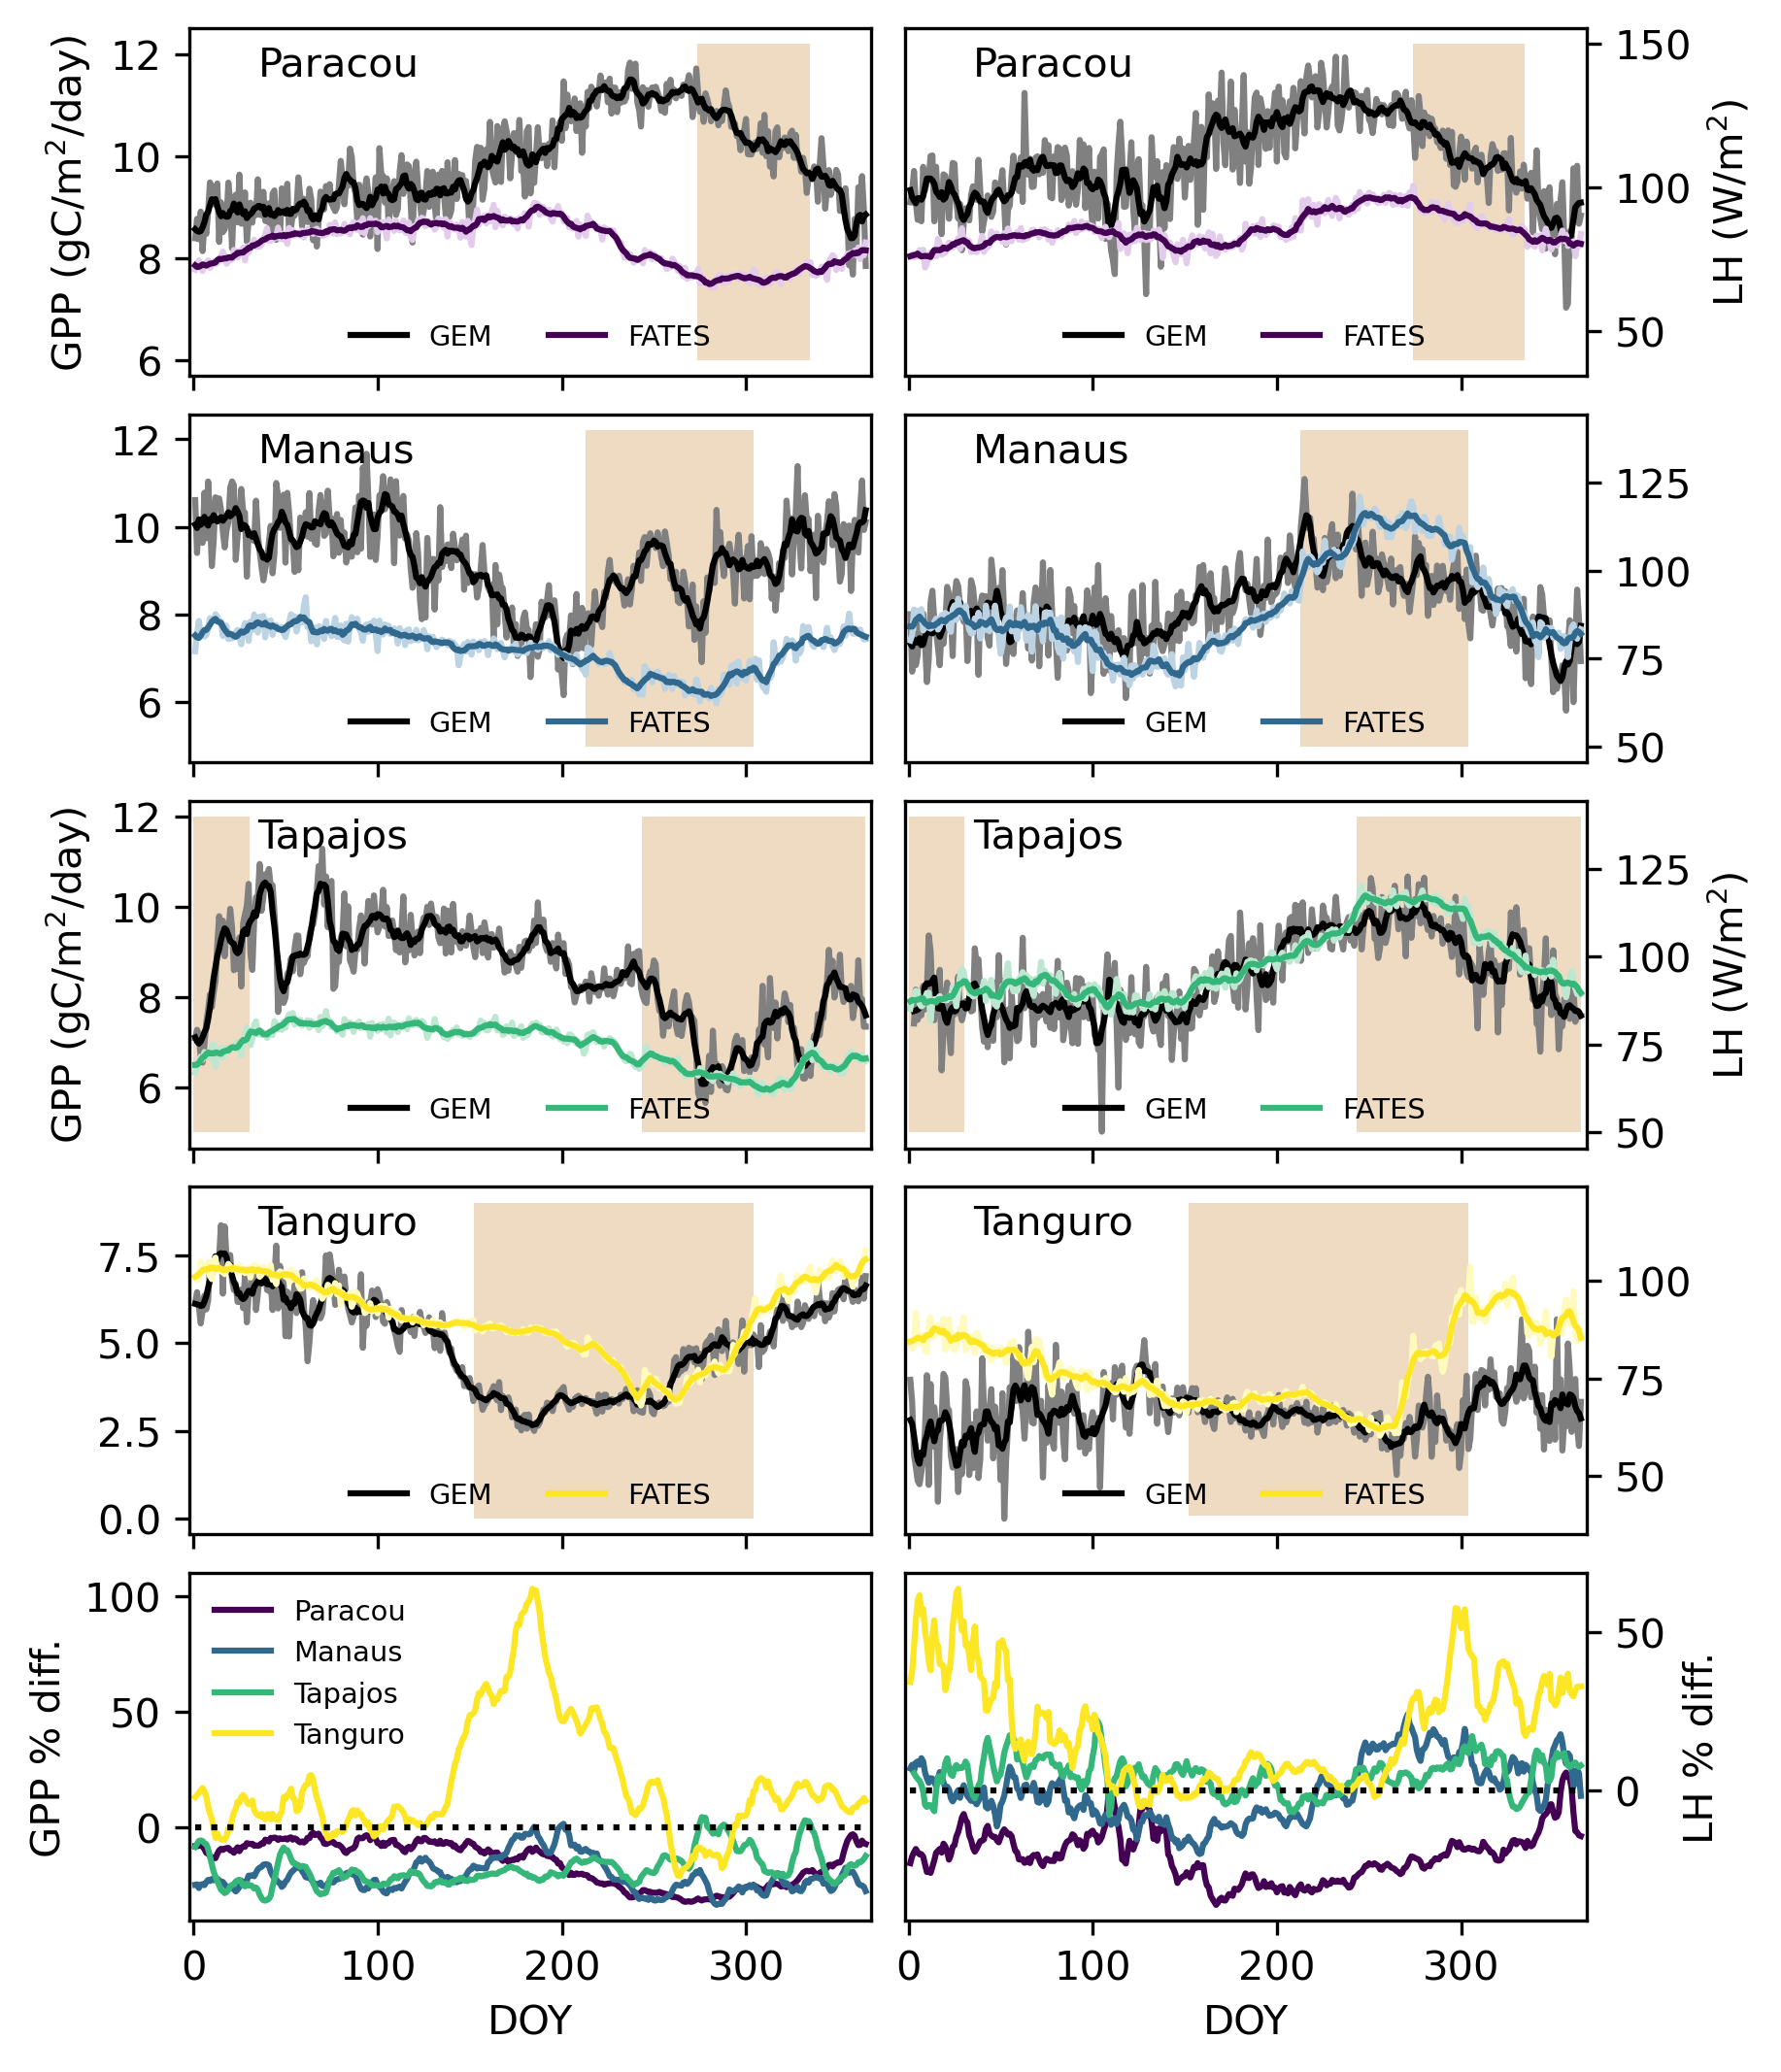

In [121]:
# Order from most to least mean annual rainfall
# add light brown bar showing dry season

fig, axes = plt.subplots(5,2, figsize=(6,7), sharex=True)

# Columns = GPP, LH
# Rows = Paracou, Manaus (K34), Tapajos, Tanguro, residuals (all)

# color scheme: observations = black
# Custom 4-color palette from Wet to Dry
# Order: Paracou (wettest) -> Manaus -> Tapajos -> Tanguro (driest)
site_colors = ['#440154', '#31688e', '#35b779', '#fde725']
shading_colors = ['#e2cbeb', '#bcd3e3', '#bee7d2', '#fffbbf']

### Row 1 - Paracou ###
# Col 1: GPP
axes[0,0].add_patch(gswp_par_dry_gpp)
axes[0,0].plot(par_jd, cf2*par_avg_GPP_R, color="grey")
axes[0,0].plot(par_jd, uniform_filter1d(cf2*par_avg_GPP_R, size=7), color="black", label="GEM")
#axes[0,0].plot(par_jd, cf2*par_avg_GPP_L, color="grey") # the two estimates of GPP are similar
#axes[0,0].plot(par_jd, uniform_filter1d(cf2*par_avg_GPP_L, size=7), color="black", label="Paracou - L")
axes[0,0].plot(fates_days, cf*fates_par_avg_GPP, color=shading_colors[0])
axes[0,0].plot(fates_days, uniform_filter1d(cf*fates_par_avg_GPP, size=7), color=site_colors[0], label="FATES")
axes[0,0].set_ylabel('GPP (gC/m$^2$/day)')
axes[0,0].text(0.1, 0.95, 'Paracou', transform=axes[0,0].transAxes, va='top', ha='left')
axes[0,0].set_xlim(-2,368)
axes[0,0].legend(loc='lower center',ncols=2,fontsize='x-small',frameon=False)
    
# Col 2: LH
axes[0,1].add_patch(gswp_par_dry_lh)
axes[0,1].plot(par_jd, par_avg_LH, color="grey")
axes[0,1].plot(par_jd, uniform_filter1d(par_avg_LH, size=7), color="black", label="GEM")
axes[0,1].plot(fates_days, fates_par_avg_LH, color=shading_colors[0])
axes[0,1].plot(fates_days, uniform_filter1d(fates_par_avg_LH, size=7), color=site_colors[0], label="FATES")
axes[0,1].set_ylabel('LH (W/m$^2$)')
axes[0,1].text(0.1, 0.95, 'Paracou', transform=axes[0,1].transAxes, va='top', ha='left')
axes[0,1].set_xlim(-2,368)
axes[0,1].yaxis.tick_right()                 # <-- Moves ticks right
axes[0,1].yaxis.set_label_position("right")  # <-- Moves label text right
axes[0,1].legend(loc='lower center',ncols=2,fontsize='x-small',frameon=False)

### Row 2 - K34 Manaus ###
## col 1: GPP
axes[1,0].add_patch(gswp_k34_dry_gpp)
axes[1,0].plot(k34_jd, k34_avg_GPP, color="grey")
axes[1,0].plot(k34_jd, uniform_filter1d(k34_avg_GPP, size=7), color="black", label="GEM")
axes[1,0].plot(fates_days, cf*fates_k34_avg_GPP, color=shading_colors[1])
axes[1,0].plot(fates_days, uniform_filter1d(cf*fates_k34_avg_GPP, size=7), color=site_colors[1], label="FATES")
#axes[1,0].set_ylabel('GPP (gC/m$^2$/day)')
axes[1,0].text(0.1, 0.95, 'Manaus', transform=axes[1,0].transAxes, va='top', ha='left')
axes[1,0].legend(loc='lower center',ncols=2,fontsize='x-small',frameon=False)

## col 2: LH
axes[1,1].add_patch(gswp_k34_dry_lh)
axes[1,1].plot(k34_jd, k34_avg_LH, color="grey")
axes[1,1].plot(k34_jd, uniform_filter1d(k34_avg_LH, size=7), color="black", label="GEM")
axes[1,1].plot(fates_days, fates_k34_avg_LH, color=shading_colors[1])
axes[1,1].plot(fates_days, uniform_filter1d(fates_k34_avg_LH, size=7), color=site_colors[1], label="FATES")
#axes[1,1].set_ylabel('LH (W/m$^2$)')
axes[1,1].text(0.1, 0.95, 'Manaus', transform=axes[1,1].transAxes, va='top', ha='left')
axes[1,1].yaxis.tick_right()                 # <-- Moves ticks right
axes[1,1].yaxis.set_label_position("right")  # <-- Moves label text right
axes[1,1].legend(loc='lower center',ncols=2,fontsize='x-small',frameon=False)

### Row 3 - Tapajos ###
## col 1: GPP
axes[2,0].add_patch(gswp_tap_dry1_gpp)
axes[2,0].add_patch(gswp_tap_dry2_gpp)
axes[2,0].plot(tap_jd, cf2*tap_avg_GPP, color="grey")
axes[2,0].plot(tap_jd, uniform_filter1d(cf2*tap_avg_GPP, size=7), color="black", label="GEM")
axes[2,0].plot(fates_days, cf*fates_tap_avg_GPP, color=shading_colors[2])
axes[2,0].plot(fates_days, uniform_filter1d(cf*fates_tap_avg_GPP, size=7), color=site_colors[2], label="FATES")
axes[2,0].set_ylabel('GPP (gC/m$^2$/day)')
axes[2,0].text(0.1, 0.95, 'Tapajos', transform=axes[2,0].transAxes, va='top', ha='left')
axes[2,0].legend(loc='lower center',ncols=2,fontsize='x-small',frameon=False)

## col 2: LH
axes[2,1].add_patch(gswp_tap_dry1_lh)
axes[2,1].add_patch(gswp_tap_dry2_lh)
axes[2,1].plot(tap_jd, tap_avg_LH, color="grey")
axes[2,1].plot(tap_jd[2:], uniform_filter1d(tap_avg_LH[2:], size=7), color="black", label="GEM")
axes[2,1].plot(fates_days, fates_tap_avg_LH, color=shading_colors[2])
axes[2,1].plot(fates_days, uniform_filter1d(fates_tap_avg_LH, size=7), color=site_colors[2], label="FATES")
axes[2,1].set_ylabel('LH (W/m$^2$)')
axes[2,1].text(0.1, 0.95, 'Tapajos', transform=axes[2,1].transAxes, va='top', ha='left')
axes[2,1].yaxis.tick_right()                 # <-- Moves ticks right
axes[2,1].yaxis.set_label_position("right")  # <-- Moves label text right
axes[2,1].legend(loc='lower center',ncols=2,fontsize='x-small',frameon=False)

### Row 4 - Tanguro ###
## col 1: GPP
axes[3,0].add_patch(gswp_tan_dry_gpp)
axes[3,0].plot(tan_jd, tan_avg_GPP, color="grey")
axes[3,0].plot(tan_jd, uniform_filter1d(tan_avg_GPP, size=7), color="black", label="GEM")
axes[3,0].plot(fates_days, cf*fates_tan_avg_GPP, color=shading_colors[3])
axes[3,0].plot(fates_days, uniform_filter1d(cf*fates_tan_avg_GPP, size=7), color=site_colors[3], label="FATES")
#axes[3,0].set_ylabel('GPP (gC/m$^2$/day)')
axes[3,0].text(0.1, 0.95, 'Tanguro', transform=axes[3,0].transAxes, va='top', ha='left')
axes[3,0].legend(loc='lower center',ncols=2,fontsize='x-small',frameon=False)
## col 2: LH
axes[3,1].add_patch(gswp_tan_dry_lh)
axes[3,1].plot(tan_jd, tan_avg_LH, color="grey")
axes[3,1].plot(tan_jd, uniform_filter1d(tan_avg_LH, size=7), color="black", label="GEM")
axes[3,1].plot(fates_days, fates_tan_avg_LH, color=shading_colors[3])
axes[3,1].plot(fates_days, uniform_filter1d(fates_tan_avg_LH, size=7), color=site_colors[3], label="FATES")
#axes[3,1].set_ylabel('LH (W/m$^2$)')
axes[3,1].text(0.1, 0.95, 'Tanguro', transform=axes[3,1].transAxes, va='top', ha='left')
axes[3,1].yaxis.tick_right()                 # <-- Moves ticks right
axes[3,1].yaxis.set_label_position("right")  # <-- Moves label text right
axes[3,1].legend(loc='lower center',ncols=2,fontsize='x-small',frameon=False)

## row 5: residuals
## col 1: GPP
axes[4,0].plot(par_jd, uniform_filter1d(100.*(cf*fates_par_avg_GPP-cf2*par_avg_GPP_R)/(cf2*par_avg_GPP_R),size=7), color=site_colors[0],label='Paracou')
axes[4,0].plot(k34_jd, uniform_filter1d(100.*(cf*fates_k34_avg_GPP-k34_avg_GPP)/(k34_avg_GPP),size=7), color=site_colors[1],label='Manaus')
axes[4,0].plot(tap_jd, uniform_filter1d(100.*(cf*fates_tap_avg_GPP-cf2*tap_avg_GPP)/(cf2*tap_avg_GPP),size=7), color=site_colors[2],label='Tapajos')
axes[4,0].plot(tan_jd, uniform_filter1d(100.*(cf*fates_tan_avg_GPP-tan_avg_GPP)/(tan_avg_GPP),size=7), color=site_colors[3],label='Tanguro')
axes[4,0].set_ylabel('GPP % diff.')
axes[4,0].plot(par_jd, 0.*par_jd, color="black",linestyle="dotted")
axes[4,0].set_xlabel('DOY')
axes[4,0].legend(loc='upper left',fontsize='x-small',frameon=False)

## col 2: LH
axes[4,1].plot(par_jd, uniform_filter1d(100.*(fates_par_avg_LH-par_avg_LH)/par_avg_LH,size=7), color=site_colors[0])
axes[4,1].plot(k34_jd, uniform_filter1d(100.*(fates_k34_avg_LH-k34_avg_LH)/k34_avg_LH,size=7), color=site_colors[1])
axes[4,1].plot(tap_jd[2:], uniform_filter1d(100.*(fates_tap_avg_LH[2:]-tap_avg_LH[2:])/tap_avg_LH[2:],size=7), color=site_colors[2])
axes[4,1].plot(tan_jd, uniform_filter1d(100.*(fates_tan_avg_LH-tan_avg_LH)/tan_avg_LH,size=7), color=site_colors[3])
axes[4,1].set_ylabel('LH % diff.')
axes[4,1].plot(k34_jd, 0.*k34_jd, color="black",linestyle="dotted")
axes[4,1].set_xlabel('DOY')
axes[4,1].yaxis.tick_right()                 # <-- Moves ticks right
axes[4,1].yaxis.set_label_position("right")  # <-- Moves label text right


plt.tight_layout()
plt.show()

In [ ]:
# Get annual mean and std of observed and modeled GPP at each site

In [122]:
print(np.nanmean(cf2*par_avg_GPP_R),np.nanstd(cf2*par_avg_GPP_R))

9.866497568506302 0.935372451089276


In [123]:
print(np.nanmean(cf*fates_par_avg_GPP),np.nanstd(cf*fates_par_avg_GPP))

8.263156481206513 0.4426640069850135


In [124]:
print(np.nanmean(100.*(cf*fates_par_avg_GPP-cf2*par_avg_GPP_R)/(cf2*par_avg_GPP_R)))

-15.39773046482931


In [125]:
print(np.nanmean(k34_avg_GPP),np.nanstd(k34_avg_GPP))

9.20781621532072 1.0097760287626731


In [126]:
print(np.nanmean(cf*fates_k34_avg_GPP),np.nanstd(cf*fates_k34_avg_GPP))

7.213782079056167 0.49748778506539215


In [127]:
print(np.nanmean(100.*(cf*fates_k34_avg_GPP-k34_avg_GPP)/(k34_avg_GPP)))

-20.900382168291554


In [128]:
print(np.nanmean(cf2*tap_avg_GPP),np.nanstd(cf2*tap_avg_GPP))

8.504834587900232 1.1541701735415262


In [129]:
print(np.nanmean(cf*fates_tap_avg_GPP),np.nanstd(cf*fates_tap_avg_GPP))

6.907675723135208 0.4643029419788162


In [130]:
print(np.nanmean(100.*(cf*fates_tap_avg_GPP[1:]-cf2*tap_avg_GPP[1:])/(cf2*tap_avg_GPP[1:])))

-17.772060567728897


In [131]:
print(np.nanmean(tan_avg_GPP),np.nanstd(tan_avg_GPP))

5.024979449657754 1.37299647656115


In [132]:
print(np.nanmean(cf*fates_tan_avg_GPP),np.nanstd(cf*fates_tan_avg_GPP))

5.710612531339854 1.1035795424572403


In [133]:
print(np.nanmean(100.*(cf*fates_tan_avg_GPP-tan_avg_GPP)/(tan_avg_GPP)))

18.714681070016205


In [198]:
# Get annual mean and std of observed and modeled LH at each site

In [136]:
print(np.nanmean(par_avg_LH),np.nanstd(par_avg_LH))

109.34422938390958 16.06324808923646


In [137]:
print(np.nanmean(fates_par_avg_LH),np.nanstd(fates_par_avg_LH))

85.33003508685387 5.7599800913289645


In [138]:
print(np.nanmean(100.*(fates_par_avg_LH-par_avg_LH)/(par_avg_LH)))

-20.527266615097194


In [139]:
print(np.nanmean(k34_avg_LH),np.nanstd(k34_avg_LH))

90.16320759931396 11.143527707568717


In [140]:
print(np.nanmean(fates_k34_avg_LH),np.nanstd(fates_k34_avg_LH))

89.53000162203018 13.484651935583257


In [141]:
print(np.nanmean(100.*(fates_k34_avg_LH-k34_avg_LH)/k34_avg_LH))

-0.22572200666907252


In [142]:
print(np.nanmean(tap_avg_LH),np.nanstd(tap_avg_LH))

94.30532267339579 12.454230016946822


In [143]:
print(np.nanmean(fates_tap_avg_LH),np.nanstd(fates_tap_avg_LH))

97.93514577787217 10.080261069928337


In [144]:
print(np.nanmean(100.*(fates_tap_avg_LH-tap_avg_LH)/tap_avg_LH))

4.7828511168726955


In [145]:
print(np.nanmean(tan_avg_LH),np.nanstd(tan_avg_LH))

65.99841230541317 7.537823589762594


In [146]:
print(np.nanmean(fates_tan_avg_LH),np.nanstd(fates_tan_avg_LH))

77.60795665375174 9.740739634994116


In [147]:
print(np.nanmean(100.*(fates_tan_avg_LH-tan_avg_LH)/tan_avg_LH))

19.15991996498424


In [215]:
# Get fraction of early PFT basal area at each site

In [217]:
d0.FATES_BASALAREA_SZPF

<xarray.DataArray 'FATES_BASALAREA_SZPF' (time: 300, fates_levscpf: 26,
                                          lat: 23, lon: 24)>
[4305600 values with dtype=float32]
Coordinates:
  * time     (time) object 0001-02-01 00:00:00 ... 0026-01-01 00:00:00
  * lon      (lon) float32 275.0 277.5 280.0 282.5 ... 325.0 327.5 330.0 332.5
  * lat      (lat) float32 -25.58 -23.68 -21.79 -19.89 ... 12.32 14.21 16.11
Dimensions without coordinates: fates_levscpf
Attributes:
    long_name:     basal area by pft/size
    units:         m2 m-2
    cell_methods:  time: mean

In [218]:
ba_szpf=fa.scpf_to_scls_by_pft(d0.FATES_BASALAREA_SZPF,d0)

In [219]:
pft_ratio=(ba_szpf.sum(dim='fates_levscls').isel(fates_levpft=0).mean(dim="time"))/(ba_szpf.sum(dim='fates_levscls').sum(dim='fates_levpft').mean(dim="time"))


In [221]:
pft_ratio.isel(lat=par_lat_ind).isel(lon=par_lon_ind).data


array(0.1803522, dtype=float32)

In [222]:
pft_ratio.isel(lat=k34_lat_ind).isel(lon=k34_lon_ind).data


array(0.55368936, dtype=float32)

In [223]:
pft_ratio.isel(lat=tap_lat_ind).isel(lon=tap_lon_ind).data


array(0.51344395, dtype=float32)

In [224]:
pft_ratio.isel(lat=tan_lat_ind).isel(lon=tan_lon_ind).data


array(0.6461408, dtype=float32)